## Creates the **Grid File** of a specific region by converting the available shapefile into mutliple (X,Y) coordinate pairs to represent each NUTS3 Unit ##

In [1]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")


from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'CMacedonia'
NUTS2_ID = 'EL52'

In [4]:
greece_nuts3_gdf = gpd.read_file(r"E:\Drive\NOA\MBD-Prediction\Europe NUTS - LAU Shapefiles\Greece\data\EL_NUTS2.shp",  encoding=enc)

In [5]:
greece_nuts3_gdf.head(5)

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [6]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]


In [7]:
greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

In [8]:
print(f'greece_nuts3 CRS: {greece_nuts3_gdf.crs}')

greece_nuts3 CRS: EPSG:4326


In [9]:
greece_nuts3_gdf.head(5)

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
0,EL62,EL,Ionia Nisia,Ιόνια Νησιά,Greece,"MULTIPOLYGON (((21.11222 38.31611, 21.11426 38..."
1,EL63,EL,Dytiki Elláda,Δυτική Ελλάδα,Greece,"MULTIPOLYGON (((22.37297 38.14222, 22.37737 38..."
2,EL41,EL,Voreio Aigaio,Βόρειο Αιγαίο,Greece,"MULTIPOLYGON (((26.95446 37.75858, 26.96711 37..."
3,EL42,EL,Notio Aigaio,Νότιο Αιγαίο,Greece,"MULTIPOLYGON (((29.63524 36.11068, 29.63181 36..."
4,EL51,EL,"Anatoliki Makedonia, Thraki","Aνατολική Μακεδονία, Θράκη",Greece,"MULTIPOLYGON (((26.35788 41.71110, 26.36917 41..."


In [10]:
greece_nuts3_gdf.NUTS_ID.unique()

array(['EL62', 'EL63', 'EL41', 'EL42', 'EL51', 'EL30', 'EL61', 'EL65',
       'EL43', 'EL52', 'EL64', 'EL54', 'EL53'], dtype=object)

In [11]:
print(f'Length of greece_nuts3_gdf: {len(greece_nuts3_gdf)}')

Length of greece_nuts3_gdf: 13


In [12]:
#choose the correct region

nuts2_gdf = greece_nuts3_gdf.loc[greece_nuts3_gdf['NUTS_ID'] == f'{NUTS2_ID}'].copy()
nuts2_gdf.head()

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
9,EL52,EL,Kentriki Makedonia,Κεντρική Μακεδονία,Greece,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [13]:
print(f'nuts2_gdf CRS: {nuts2_gdf.crs}')

nuts2_gdf CRS: EPSG:4326


<Axes: >

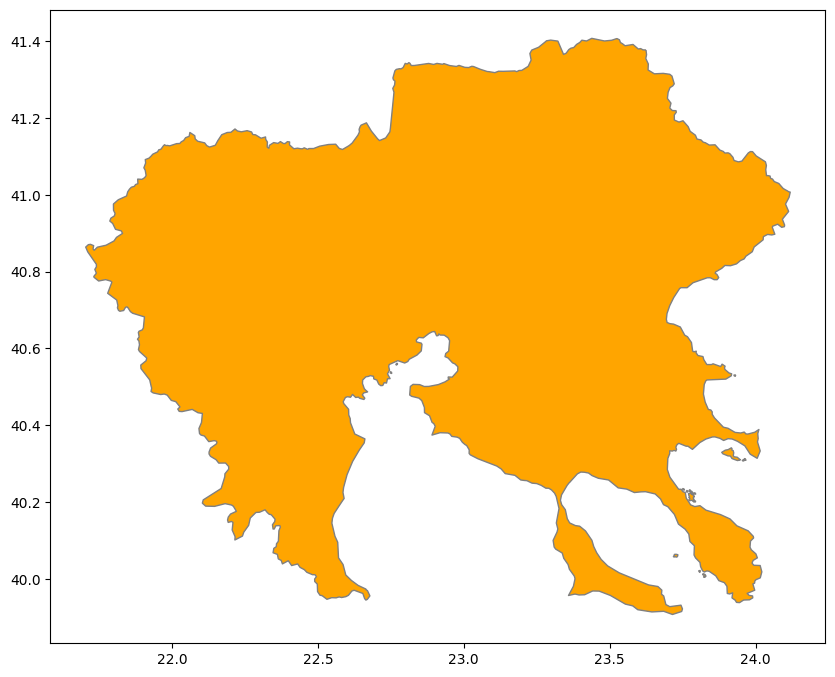

In [14]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [15]:
nuts2_gdf

,NUTS_ID,CNTR_CODE,NAME_LATN,NUTS_NAME,CNTR_NAME,geometry
9,EL52,EL,Kentriki Makedonia,Κεντρική Μακεδονία,Greece,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


In [16]:
nuts2_gdf.drop(columns=['CNTR_CODE','NAME_LATN','CNTR_NAME'], inplace = True)
nuts2_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts2_gdf, 'NUTS_NAME')


In [17]:
nuts2_gdf.head(5)

,NUTS_ID,NUTS_NAME,geometry
0,EL52,κεντρικη μακεδονια,"MULTIPOLYGON (((23.62422 41.37573, 23.62617 41..."


<Axes: >

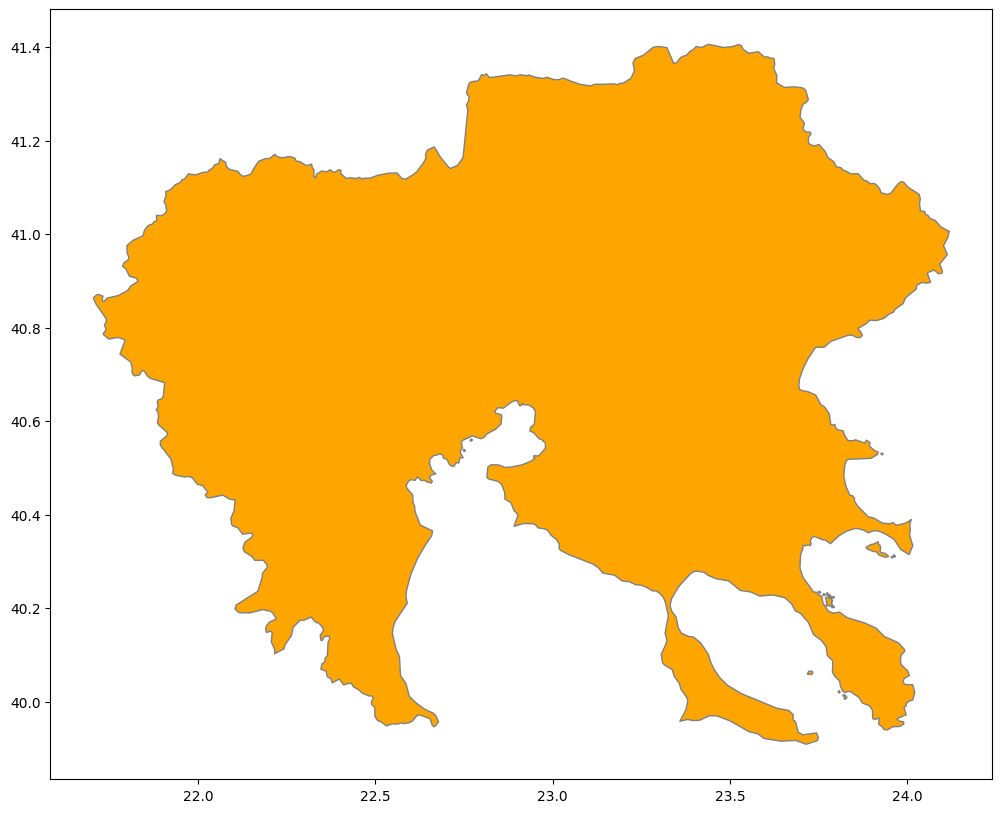

In [18]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(15, 10), color='orange')

In [19]:
nuts2_gdf.reset_index(inplace=True, drop = True)

In [20]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal='NUTS_ID', dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [21]:
df_grid.shape

(4416, 5)

In [22]:
df_grid.head()

,geometry,centers,NAME,x,y
0,"POLYGON ((21.77505 40.78908, 21.77505 40.80705...",POINT (21.76333741471462 40.79806323421062),EL52,21.76334,40.79806
1,"POLYGON ((21.77505 40.80705, 21.77505 40.82501...",POINT (21.76333741471462 40.816029925810845),EL52,21.76334,40.81603
2,"POLYGON ((21.77505 40.82501, 21.77505 40.84298...",POINT (21.76333741471462 40.83399661741106),EL52,21.76334,40.83400
3,"POLYGON ((21.77505 40.84298, 21.77505 40.86095...",POINT (21.76333741471462 40.85196330901128),EL52,21.76334,40.85196
4,"POLYGON ((21.79847 40.78908, 21.79847 40.80705...",POINT (21.786759980600472 40.79806323421062),EL52,21.78676,40.79806


In [23]:
df_grid.rename(columns={"NAME": "NUTS2_ID"}, inplace = True)

<Axes: >

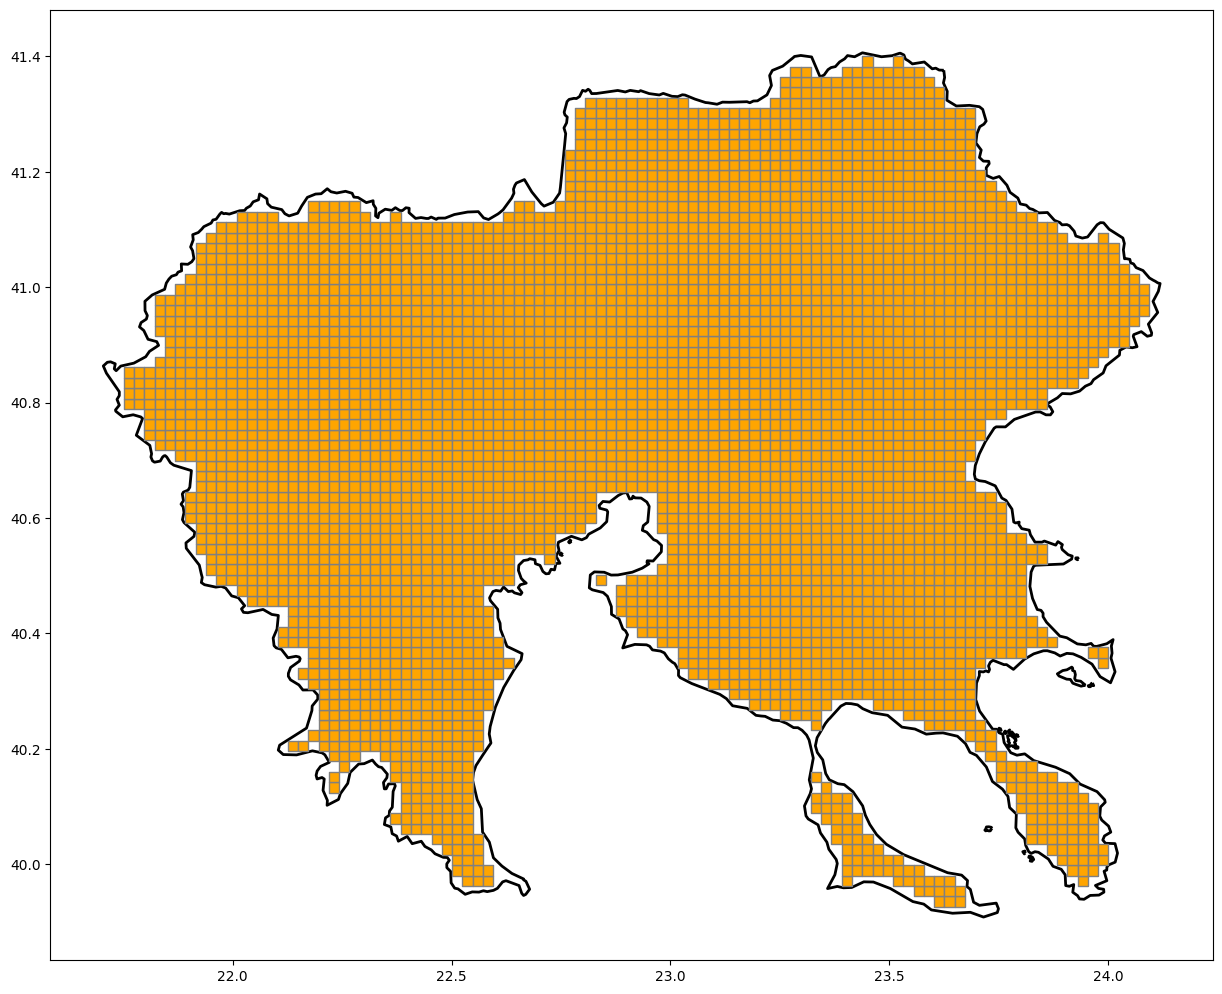

In [24]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [25]:
nuts2_grid = df_grid.drop(columns=['centers'])

In [26]:
nuts2_grid['cell_number'] = nuts2_grid.index

In [27]:
nuts2_grid

,geometry,NUTS2_ID,x,y,cell_number
0,"POLYGON ((21.77505 40.78908, 21.77505 40.80705...",EL52,21.76334,40.79806,0
1,"POLYGON ((21.77505 40.80705, 21.77505 40.82501...",EL52,21.76334,40.81603,1
2,"POLYGON ((21.77505 40.82501, 21.77505 40.84298...",EL52,21.76334,40.83400,2
3,"POLYGON ((21.77505 40.84298, 21.77505 40.86095...",EL52,21.76334,40.85196,3
4,"POLYGON ((21.79847 40.78908, 21.79847 40.80705...",EL52,21.78676,40.79806,4
...,...,...,...,...,...
4411,"POLYGON ((24.07046 40.98671, 24.07046 41.00468...",EL52,24.05875,40.99570,4411
4412,"POLYGON ((24.07046 41.00468, 24.07046 41.02265...",EL52,24.05875,41.01366,4412
4413,"POLYGON ((24.09388 40.95078, 24.09388 40.96875...",EL52,24.08217,40.95976,4413
4414,"POLYGON ((24.09388 40.96875, 24.09388 40.98671...",EL52,24.08217,40.97773,4414


In [28]:
nuts2_grid_points = gpd.GeoDataFrame(nuts2_grid, geometry=gpd.points_from_xy(nuts2_grid.x, nuts2_grid.y))

In [29]:
nuts2_grid_points

,geometry,NUTS2_ID,x,y,cell_number
0,POINT (21.76334 40.79806),EL52,21.76334,40.79806,0
1,POINT (21.76334 40.81603),EL52,21.76334,40.81603,1
2,POINT (21.76334 40.83400),EL52,21.76334,40.83400,2
3,POINT (21.76334 40.85196),EL52,21.76334,40.85196,3
4,POINT (21.78676 40.79806),EL52,21.78676,40.79806,4
...,...,...,...,...,...
4411,POINT (24.05875 40.99570),EL52,24.05875,40.99570,4411
4412,POINT (24.05875 41.01366),EL52,24.05875,41.01366,4412
4413,POINT (24.08217 40.95976),EL52,24.08217,40.95976,4413
4414,POINT (24.08217 40.97773),EL52,24.08217,40.97773,4414


<Axes: >

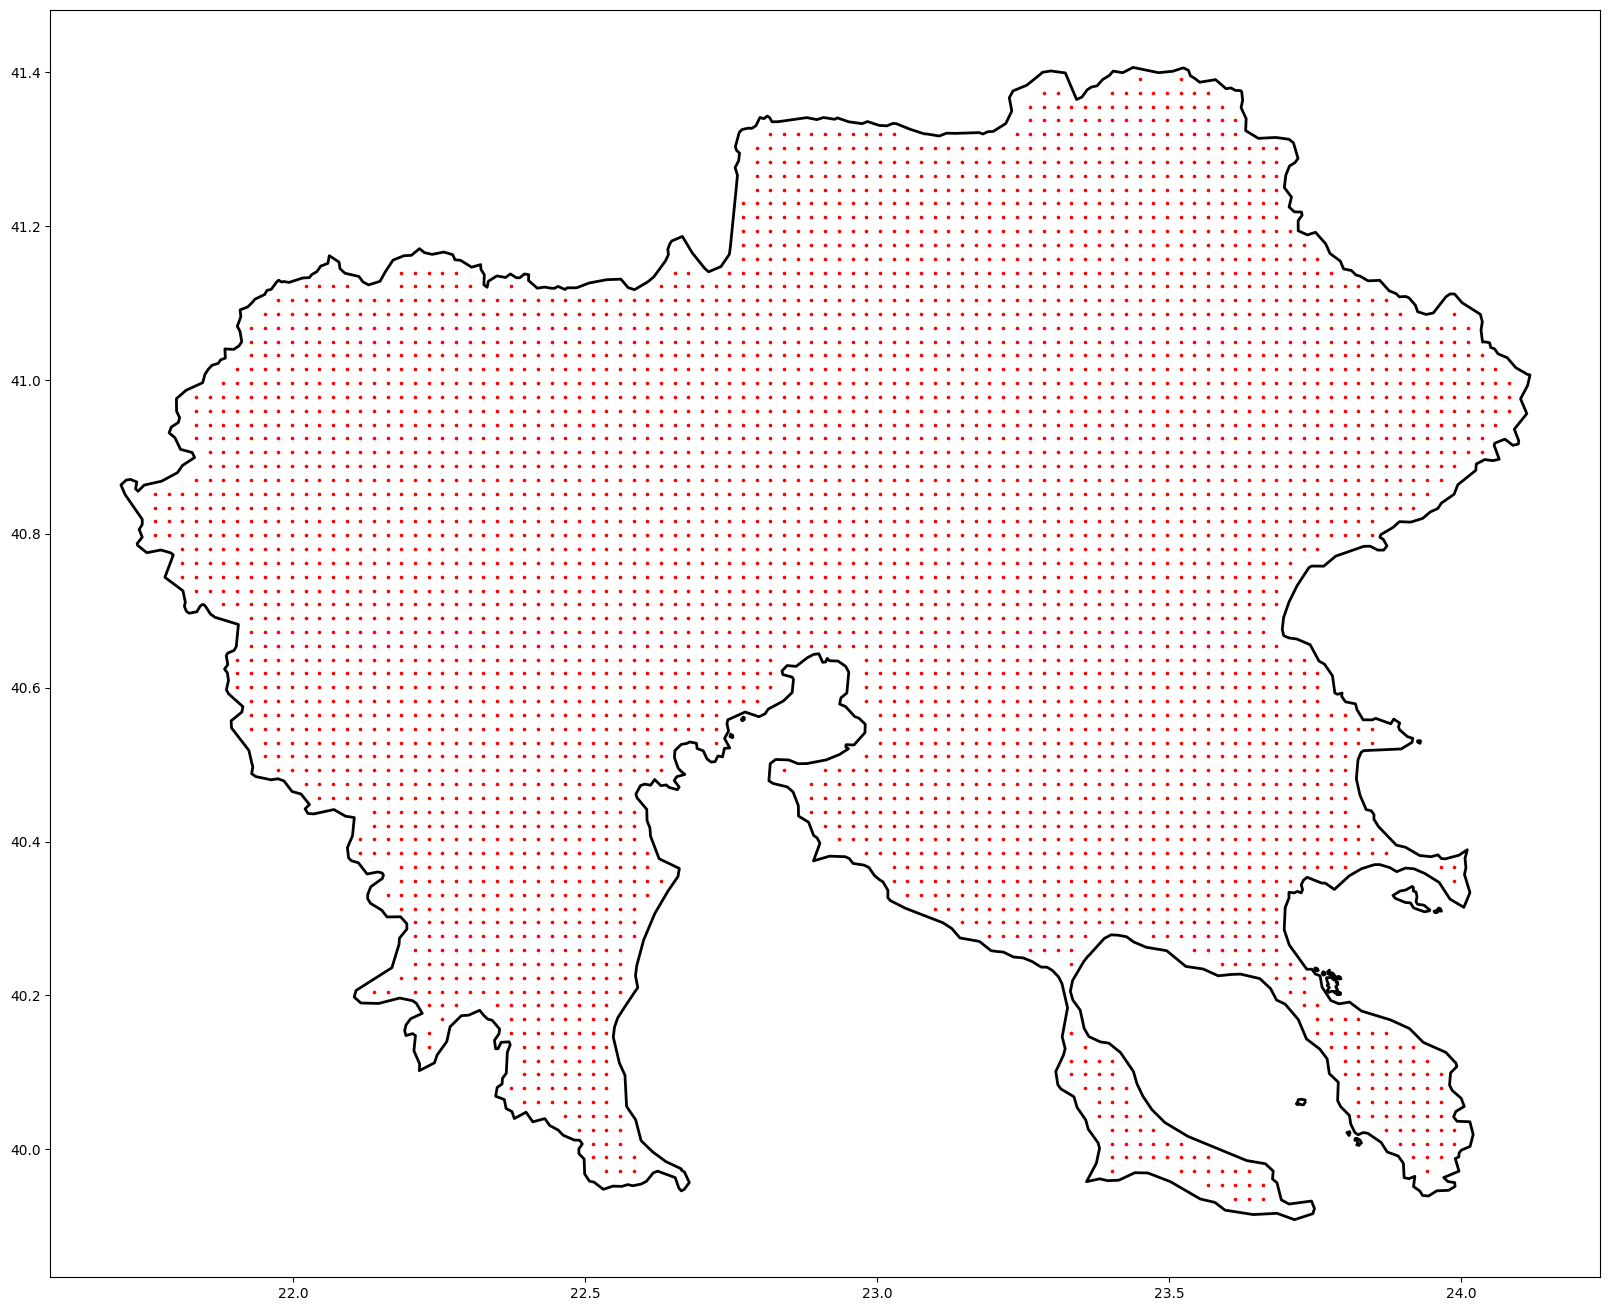

In [30]:
ax = nuts2_grid_points.plot(markersize=2.5, figsize=(20, 20), color='red')
nuts2_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [31]:
final_grid = nuts2_grid[['cell_number', 'NUTS2_ID', 'x', 'y', 'geometry']]

final_grid.reset_index(drop = True, inplace= True)

In [32]:
final_grid

,cell_number,NUTS2_ID,x,y,geometry
0,0,EL52,21.76334,40.79806,"POLYGON ((21.77505 40.78908, 21.77505 40.80705..."
1,1,EL52,21.76334,40.81603,"POLYGON ((21.77505 40.80705, 21.77505 40.82501..."
2,2,EL52,21.76334,40.83400,"POLYGON ((21.77505 40.82501, 21.77505 40.84298..."
3,3,EL52,21.76334,40.85196,"POLYGON ((21.77505 40.84298, 21.77505 40.86095..."
4,4,EL52,21.78676,40.79806,"POLYGON ((21.79847 40.78908, 21.79847 40.80705..."
...,...,...,...,...,...
4411,4411,EL52,24.05875,40.99570,"POLYGON ((24.07046 40.98671, 24.07046 41.00468..."
4412,4412,EL52,24.05875,41.01366,"POLYGON ((24.07046 41.00468, 24.07046 41.02265..."
4413,4413,EL52,24.08217,40.95976,"POLYGON ((24.09388 40.95078, 24.09388 40.96875..."
4414,4414,EL52,24.08217,40.97773,"POLYGON ((24.09388 40.96875, 24.09388 40.98671..."


In [33]:
final_grid.drop(columns='geometry')

,cell_number,NUTS2_ID,x,y
0,0,EL52,21.76334,40.79806
1,1,EL52,21.76334,40.81603
2,2,EL52,21.76334,40.83400
3,3,EL52,21.76334,40.85196
4,4,EL52,21.78676,40.79806
...,...,...,...,...
4411,4411,EL52,24.05875,40.99570
4412,4412,EL52,24.05875,41.01366
4413,4413,EL52,24.08217,40.95976
4414,4414,EL52,24.08217,40.97773


In [34]:
final_grid.drop(columns='geometry').to_csv(f'../../data/CMacedonia/GR_CMacedonia_GRID.csv', encoding=enc, index = False)

In [35]:
final_grid.to_file(f'../../data/CMacedonia/GR_CMacedonia_GRID.shp', encoding = 'utf-8')